# Линейная регрессия: переобучение и регуляризация

Исследуем, как степень полинома влияет на ошибку, и сравним Linear Regression, Ridge и Lasso на сложном признаковом пространстве.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")

## Данные

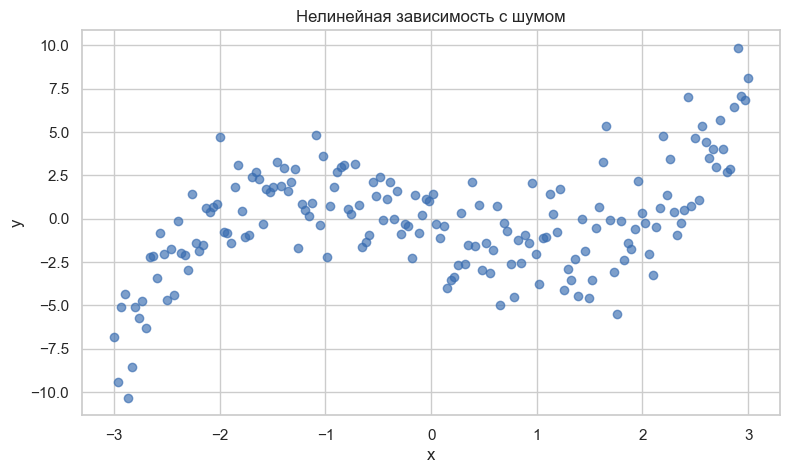

In [2]:
rng = np.random.default_rng(42)
x = np.linspace(-3, 3, 180)
y = 0.5 * x ** 3 - 2 * x + rng.normal(0, 2.2, len(x))
features = x.reshape(-1, 1)
train_features, test_features, train_target, test_target = train_test_split(
    features, y, test_size=0.3, random_state=42
)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.65, color="#386cb0")
plt.title("Нелинейная зависимость с шумом")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Сложность модели

,degree,train_mse,test_mse
0,1,8.543336,8.131240
1,2,8.543200,8.139569
2,3,3.468397,3.878207
3,5,3.413411,3.883262
4,8,3.410406,3.907796
5,12,3.313924,4.251392
6,15,3.247290,4.457028


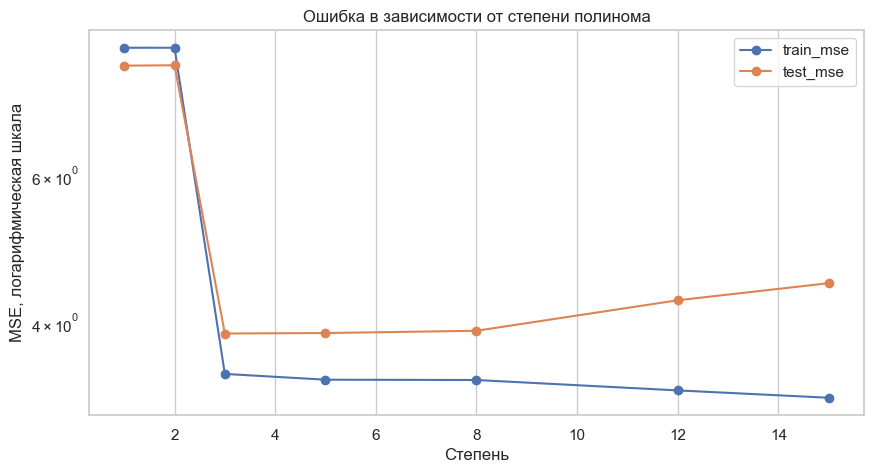

In [3]:
degree_rows = []
for degree in [1, 2, 3, 5, 8, 12, 15]:
    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression()),
    ])
    model.fit(train_features, train_target)
    degree_rows.append({
        "degree": degree,
        "train_mse": mean_squared_error(train_target, model.predict(train_features)),
        "test_mse": mean_squared_error(test_target, model.predict(test_features)),
    })

degree_results = pd.DataFrame(degree_rows)
display(degree_results)

degree_results.set_index("degree")[["train_mse", "test_mse"]].plot(marker="o", figsize=(10, 5))
plt.yscale("log")
plt.title("Ошибка в зависимости от степени полинома")
plt.xlabel("Степень")
plt.ylabel("MSE, логарифмическая шкала")
plt.show()

## Регуляризация

,train_mse,test_mse
model,,
Linear Regression,3.247290,4.457028
Ridge,3.813081,4.161503
Lasso,3.489098,3.902027


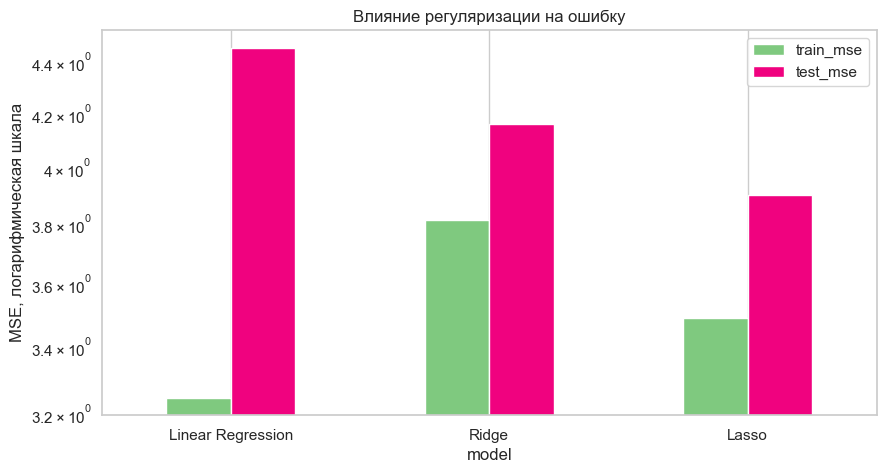

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.03, max_iter=100000),
}
regularization_rows = []
fitted_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("polynomial", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    pipeline.fit(train_features, train_target)
    fitted_models[name] = pipeline
    regularization_rows.append({
        "model": name,
        "train_mse": mean_squared_error(train_target, pipeline.predict(train_features)),
        "test_mse": mean_squared_error(test_target, pipeline.predict(test_features)),
    })

regularization_results = pd.DataFrame(regularization_rows).set_index("model")
display(regularization_results)
regularization_results.plot.bar(figsize=(10, 5), color=["#7fc97f", "#f0027f"])
plt.yscale("log")
plt.title("Влияние регуляризации на ошибку")
plt.ylabel("MSE, логарифмическая шкала")
plt.xticks(rotation=0)
plt.show()

## Кривые моделей

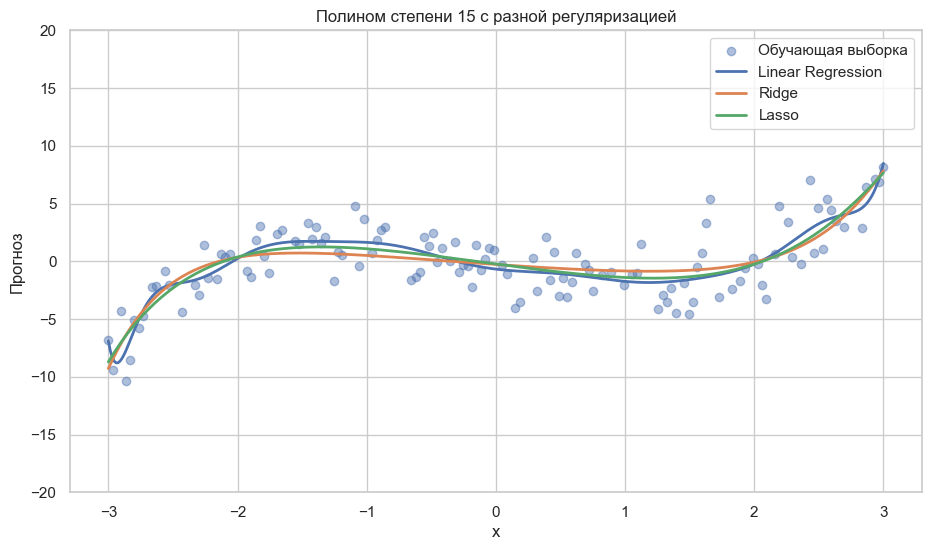

In [5]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)
plt.figure(figsize=(11, 6))
plt.scatter(train_features[:, 0], train_target, alpha=0.45, label="Обучающая выборка")
for name, model in fitted_models.items():
    plt.plot(grid[:, 0], model.predict(grid), linewidth=2, label=name)
plt.ylim(-20, 20)
plt.title("Полином степени 15 с разной регуляризацией")
plt.xlabel("x")
plt.ylabel("Прогноз")
plt.legend()
plt.show()

## Вывод

Рост сложности снижает ошибку на обучении, но после оптимальной степени test-ошибка увеличивается. Ridge и Lasso ограничивают коэффициенты и уменьшают переобучение.

## Расширенный анализ bias-variance trade-off

In [6]:
from sklearn.model_selection import KFold, learning_curve

### Норма коэффициентов при росте сложности

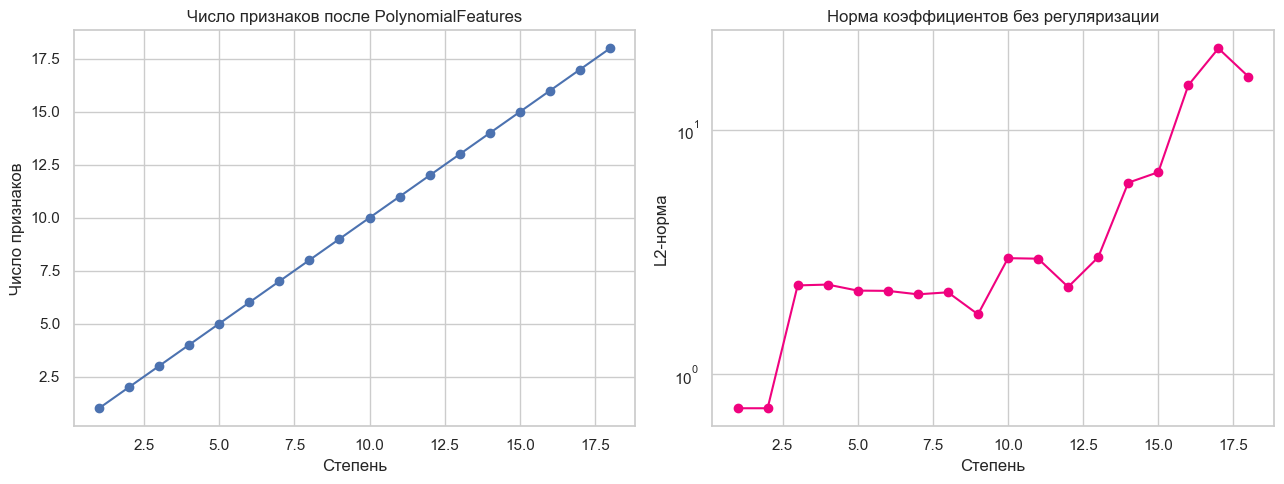

In [7]:
complexity_rows = []
for degree in range(1, 19):
    polynomial = PolynomialFeatures(degree=degree, include_bias=False)
    transformed = polynomial.fit_transform(train_features)
    estimator = LinearRegression().fit(transformed, train_target)
    complexity_rows.append({
        "degree": degree,
        "features": transformed.shape[1],
        "coefficient_norm": np.linalg.norm(estimator.coef_),
    })

complexity = pd.DataFrame(complexity_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(complexity["degree"], complexity["features"], marker="o")
axes[0].set_title("Число признаков после PolynomialFeatures")
axes[0].set_xlabel("Степень")
axes[0].set_ylabel("Число признаков")
axes[1].semilogy(complexity["degree"], complexity["coefficient_norm"], marker="o", color="#f0027f")
axes[1].set_title("Норма коэффициентов без регуляризации")
axes[1].set_xlabel("Степень")
axes[1].set_ylabel("L2-норма")
plt.tight_layout()
plt.show()

### Подбор alpha для Ridge

,value
alpha,0.789652
train_mse,3.446068
test_mse,3.888310
coefficient_norm,4.313232


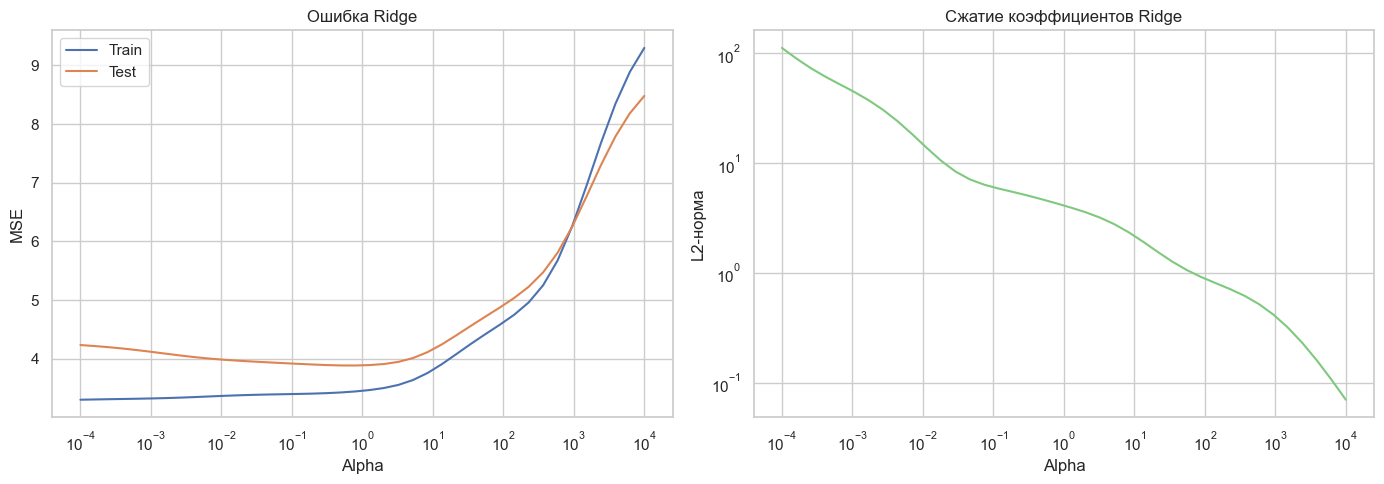

In [8]:
ridge_rows = []
for alpha in np.logspace(-4, 4, 40):
    candidate = Pipeline([
        ("polynomial", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha)),
    ])
    candidate.fit(train_features, train_target)
    ridge_rows.append({
        "alpha": alpha,
        "train_mse": mean_squared_error(train_target, candidate.predict(train_features)),
        "test_mse": mean_squared_error(test_target, candidate.predict(test_features)),
        "coefficient_norm": np.linalg.norm(candidate.named_steps["model"].coef_),
    })

ridge_sweep = pd.DataFrame(ridge_rows)
best_ridge = ridge_sweep.loc[ridge_sweep["test_mse"].idxmin()]
display(best_ridge.to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].semilogx(ridge_sweep["alpha"], ridge_sweep["train_mse"], label="Train")
axes[0].semilogx(ridge_sweep["alpha"], ridge_sweep["test_mse"], label="Test")
axes[0].set_title("Ошибка Ridge")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[1].loglog(ridge_sweep["alpha"], ridge_sweep["coefficient_norm"], color="#7fc97f")
axes[1].set_title("Сжатие коэффициентов Ridge")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("L2-норма")
plt.tight_layout()
plt.show()

### Разреженность Lasso

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.345e+01, tolerance: 1.276e-01
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.104e+00, tolerance: 1.276e-01
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.283e+00, tolerance: 1.276e-01
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.982e-01, tolerance: 1.276e-01
  model = cd_fast.enet_coordinate_descent(


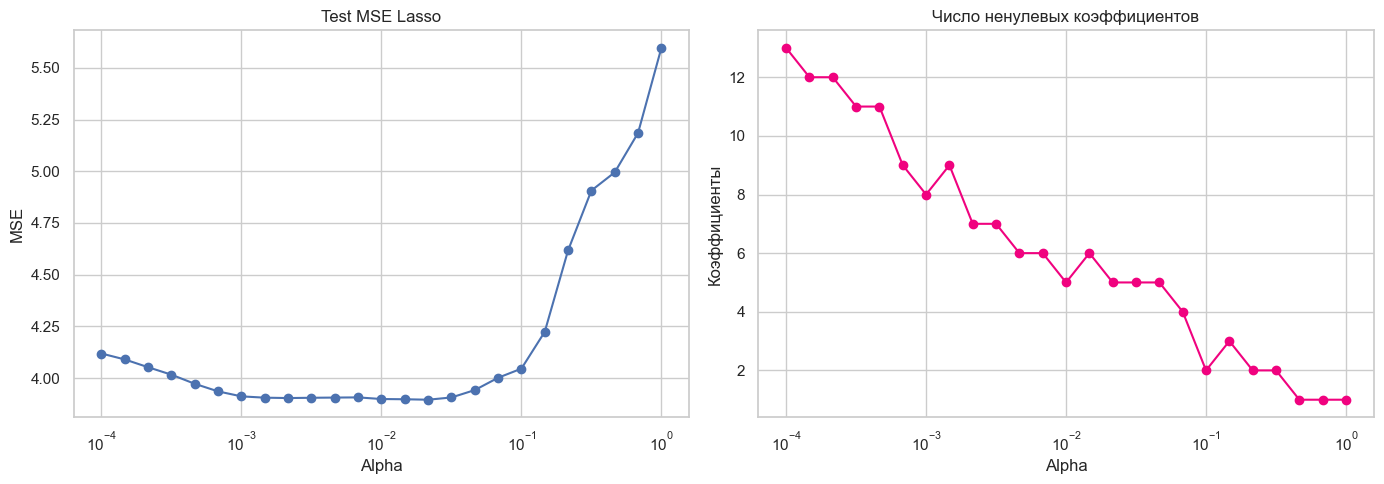

In [9]:
lasso_rows = []
for alpha in np.logspace(-4, 0, 25):
    candidate = Pipeline([
        ("polynomial", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=200000)),
    ])
    candidate.fit(train_features, train_target)
    coefficients = candidate.named_steps["model"].coef_
    lasso_rows.append({
        "alpha": alpha,
        "test_mse": mean_squared_error(test_target, candidate.predict(test_features)),
        "nonzero_coefficients": int(np.count_nonzero(np.abs(coefficients) > 1e-8)),
    })

lasso_sweep = pd.DataFrame(lasso_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].semilogx(lasso_sweep["alpha"], lasso_sweep["test_mse"], marker="o")
axes[0].set_title("Test MSE Lasso")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("MSE")
axes[1].semilogx(lasso_sweep["alpha"], lasso_sweep["nonzero_coefficients"], marker="o", color="#f0027f")
axes[1].set_title("Число ненулевых коэффициентов")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Коэффициенты")
plt.tight_layout()
plt.show()

### Learning curves для простой и сложной модели

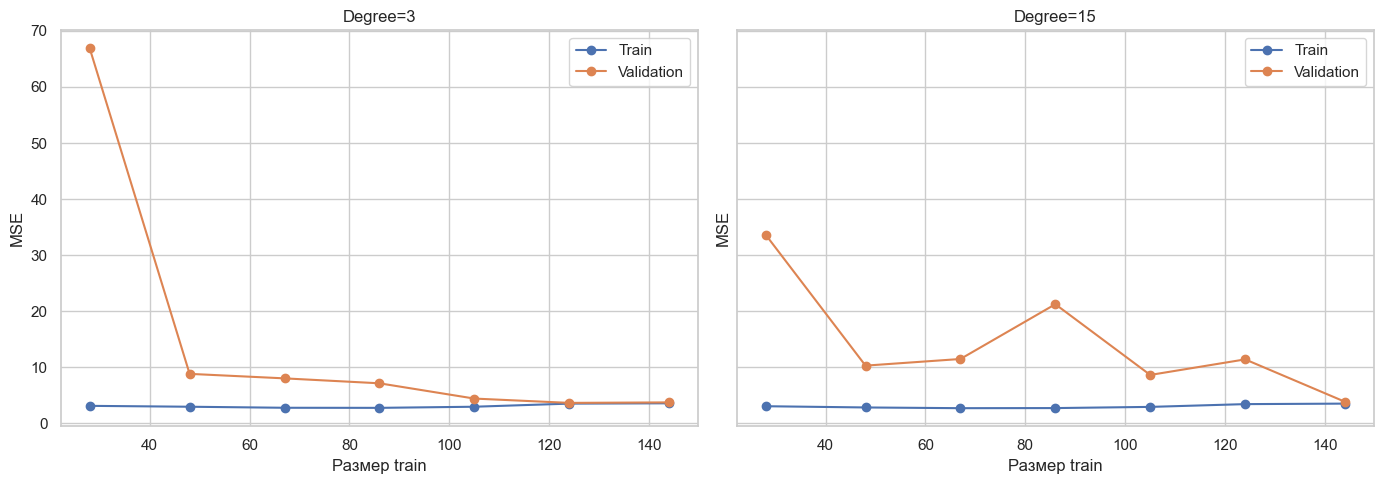

In [10]:
validation = KFold(n_splits=5, shuffle=True, random_state=42)
learning_rows = []
for degree in [3, 15]:
    candidate = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])
    sizes, train_scores, validation_scores = learning_curve(
        candidate,
        features,
        y,
        cv=validation,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 7),
    )
    for size, train_score, validation_score in zip(sizes, train_scores.mean(axis=1), validation_scores.mean(axis=1)):
        learning_rows.append({
            "degree": degree,
            "train_size": size,
            "train_mse": -train_score,
            "validation_mse": -validation_score,
        })

learning_results = pd.DataFrame(learning_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, degree in zip(axes, [3, 15]):
    subset = learning_results[learning_results["degree"] == degree]
    axis.plot(subset["train_size"], subset["train_mse"], marker="o", label="Train")
    axis.plot(subset["train_size"], subset["validation_mse"], marker="o", label="Validation")
    axis.set_title(f"Degree={degree}")
    axis.set_xlabel("Размер train")
    axis.set_ylabel("MSE")
    axis.legend()
plt.tight_layout()
plt.show()

### Диагностика лучшей Ridge-модели

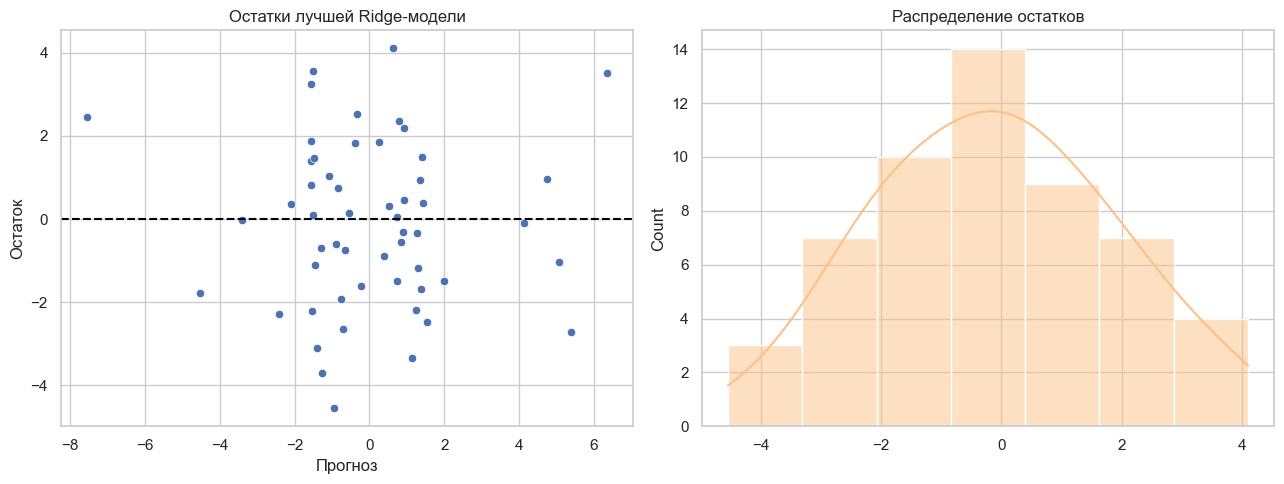

In [11]:
best_ridge_model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=15, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_ridge["alpha"])),
])
best_ridge_model.fit(train_features, train_target)
best_prediction = best_ridge_model.predict(test_features)
best_residuals = test_target - best_prediction

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=best_prediction, y=best_residuals, ax=axes[0])
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Остатки лучшей Ridge-модели")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Остаток")
sns.histplot(best_residuals, kde=True, ax=axes[1], color="#fdc086")
axes[1].set_title("Распределение остатков")
plt.tight_layout()
plt.show()

### Итог расширенного анализа

Переобучение проявляется одновременно в разрыве train/test-ошибок и резком росте коэффициентов. Ridge плавно сжимает коэффициенты, а Lasso дополнительно выполняет отбор признаков. Learning curves показывают, помогает ли модели увеличение выборки.